# Quick look at the run output

In [1]:
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cmocean import cm
import warnings

# for thalweg
from salishsea_tools import visualisations as vis
import netCDF4 as nc

warnings.simplefilter('ignore')

In [5]:
# booleans describing the different regions of analysis
def booleans(mydata,region,depth):

    if depth==50:
        depth_bool = (mydata.deptht>40) & (mydata.deptht<60)
    elif depth==0:
        depth_bool = (mydata.deptht<2)


    # region can be jdf, pug (puget sound), nsg (northern SoG), and csg (central SoG)
    # based on boxes on map
    if region == 'jdf':
        y_bool = (mydata.y >=310) & (mydata.y <360) 
        x_bool = (mydata.x >=50) & (mydata.x<100)
    
    elif region == 'pug':
        y_bool = (mydata.y >=80) & (mydata.y <130)
        x_bool = (mydata.x >=220) & (mydata.x<270)

    elif region == 'nsg':
        y_bool = (mydata.y >=650) & (mydata.y <700)
        x_bool = (mydata.x >=130) & (mydata.x<180)

    elif region == 'csg':
        y_bool = (mydata.y >=460) & (mydata.y <510)
        x_bool = (mydata.x >=240) & (mydata.x<290)

    else:
        print("invalid region name")

    return depth_bool, y_bool, x_bool

In [3]:
# bathymetry for masking land values
bath = xr.open_dataset("/home/rbeutel/MEOPAR/grid/bathymetry_202108.nc") 

# new files
path_new = Path("/scratch/rbeutel/MEOPAR/results/SS_rivertest/")
change =xr.open_mfdataset(sorted(path_new.glob(f"SalishSea_1d_20180101_20180422_pri_T_2018*.nc"))).where(~np.isnan(bath.Bathymetry))

# original salishseacast - maybe not worth it since so little is loaded on fir
path_old = Path("/home/rbeutel/projects/def-allen/SalishSea/nowcast-green.202111/")
old =xr.open_mfdataset(sorted(path_old.glob(f"*18/SalishSea_1d_*_grid_T.nc"))).where(~np.isnan(bath.Bathymetry))

In [6]:
# other grid files for thalweg plots
bathy = nc.Dataset("/home/rbeutel/MEOPAR/grid/bathymetry_202108.nc")
mesh = nc.Dataset('//home/rbeutel/MEOPAR/grid/mesh_mask201702.nc')
thalweg_in = '/home/rbeutel/MEOPAR/analysis/thalweg_working.txt'


## temperature

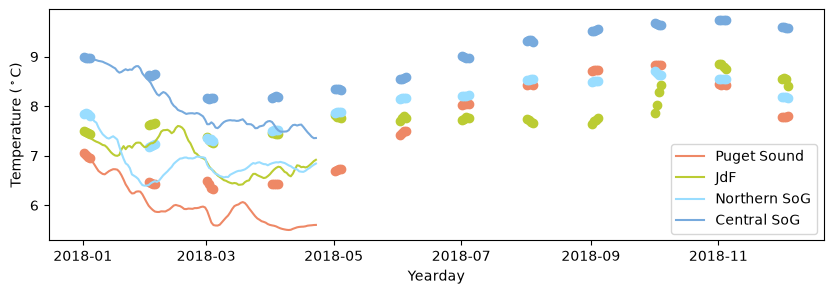

In [8]:
fig, ax = plt.subplots(1,1,figsize=(10,3))

depth_bool, y_bool, x_bool = booleans(change,'pug',depth=50)
ax.plot(change.time_counter,np.mean(change.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',label='Puget Sound')
ax.scatter(old.time_counter,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866')

depth_bool, y_bool, x_bool = booleans(change,'jdf',depth=50)
ax.plot(change.time_counter,np.mean(change.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',label='JdF')
ax.scatter(old.time_counter,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33')

depth_bool, y_bool, x_bool = booleans(change,'nsg',depth=50)
ax.plot(change.time_counter,np.mean(change.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',label='Northern SoG')
ax.scatter(old.time_counter,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF')

depth_bool, y_bool, x_bool = booleans(change,'csg',depth=50)
ax.plot(change.time_counter,np.mean(change.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',label='Central SoG')
ax.scatter(old.time_counter,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD')

ax.set_ylabel('Temperature ($^\circ$C)')
ax.set_xlabel('Yearday')
ax.legend()

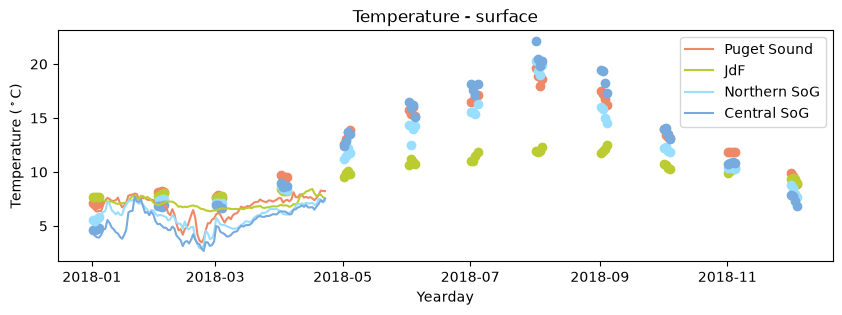

In [9]:
fig, ax = plt.subplots(1,1,figsize=(10,3))

depth_bool, y_bool, x_bool = booleans(change,'pug',depth=0)
ax.plot(change.time_counter,np.mean(change.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',label='Puget Sound')
ax.scatter(old.time_counter,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866')

depth_bool, y_bool, x_bool = booleans(change,'jdf',depth=0)
ax.plot(change.time_counter,np.mean(change.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',label='JdF')
ax.scatter(old.time_counter,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33')

depth_bool, y_bool, x_bool = booleans(change,'nsg',depth=0)
ax.plot(change.time_counter,np.mean(change.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',label='Northern SoG')
ax.scatter(old.time_counter,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF')

depth_bool, y_bool, x_bool = booleans(change,'csg',depth=0)
ax.plot(change.time_counter,np.mean(change.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',label='Central SoG')
ax.scatter(old.time_counter,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD')

ax.set_ylabel('Temperature ($^\circ$C)')
ax.set_xlabel('Yearday')
ax.set_title("Temperature - surface")
ax.legend()

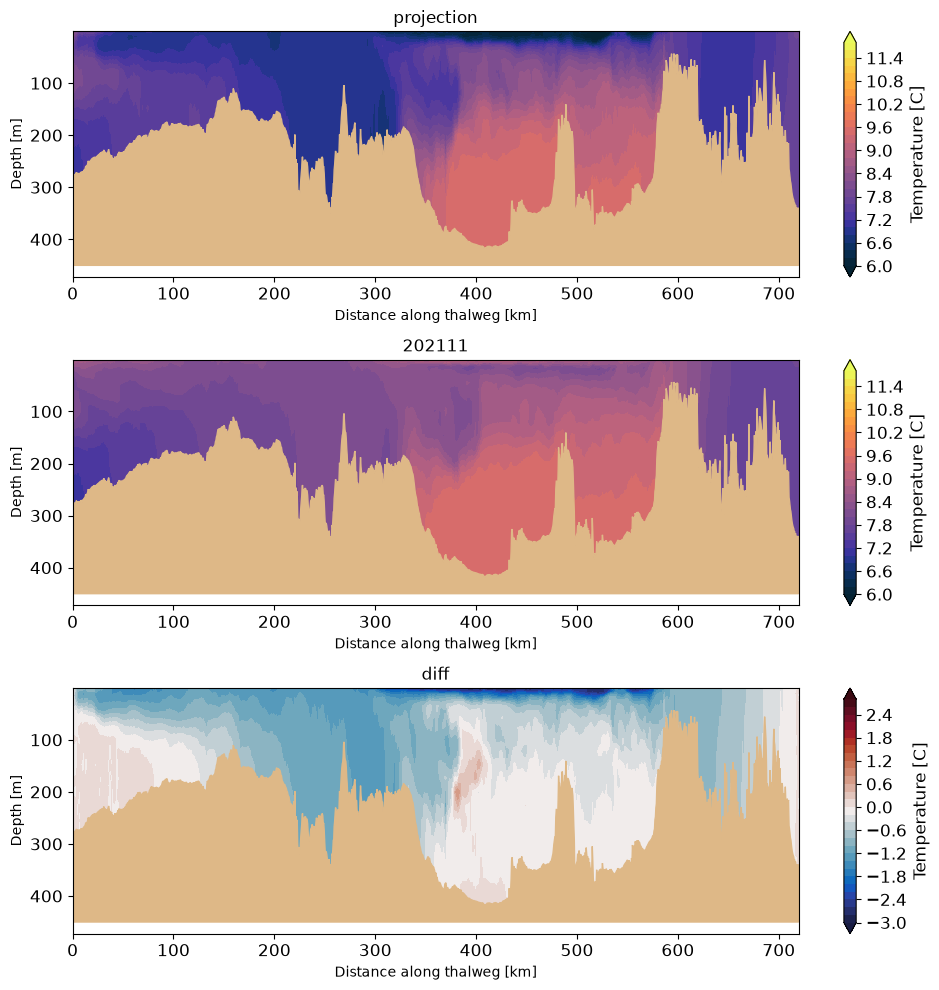

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1,figsize=(10,10))

temp_range = np.arange(6,12,0.2)
temp_diff = np.arange(-3,+3,0.2)

#projection
tit = 'projection'
data_to_plot = change['votemper'].isel(time_counter=list(change.time_counter.values).index(np.datetime64('2018-04-01T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax1, data_to_plot, bathy, mesh, clevels=temp_range, cmap = cm.thermal, thalweg_file=thalweg_in)
cbar.set_label('Temperature [C]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title(tit)

#original
tit = '202111'

data_to_plot = old['votemper'].isel(time_counter=list(old.time_counter.values).index(np.datetime64('2018-04-01T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax2, data_to_plot, bathy, mesh, clevels=temp_range, cmap = cm.thermal, thalweg_file=thalweg_in)
cbar.set_label('Temperature [C]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title(tit)

#change
tit = 'diff'
data_to_plot = change['votemper'].isel(time_counter=list(change.time_counter.values).index(np.datetime64('2018-04-01T12:00:00.000000000'))).values - old['votemper'].isel(time_counter=list(old.time_counter.values).index(np.datetime64('2018-04-01T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax3, data_to_plot, bathy, mesh, clevels=temp_diff, cmap = cm.balance, thalweg_file=thalweg_in)
cbar.set_label('Temperature [C]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_title(tit)

plt.tight_layout()

## salinity

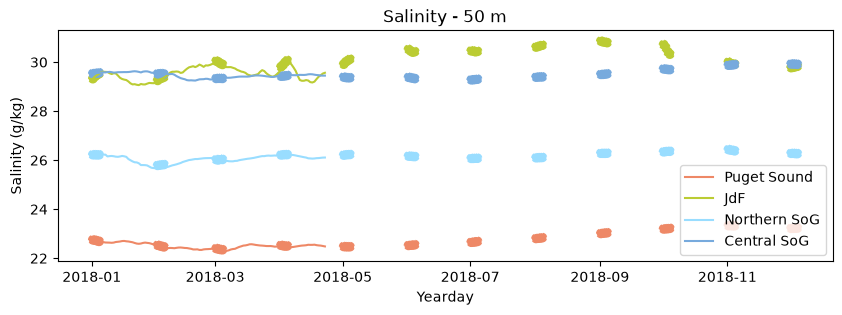

In [11]:
fig, ax = plt.subplots(1,1,figsize=(10,3))

depth_bool, y_bool, x_bool = booleans(change,'pug',depth=50)
ax.plot(change.time_counter,np.mean(change.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',label='Puget Sound')
ax.scatter(old.time_counter,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'jdf',depth=50)
ax.plot(change.time_counter,np.mean(change.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',label='JdF')
ax.scatter(old.time_counter,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'nsg',depth=50)
ax.plot(change.time_counter,np.mean(change.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',label='Northern SoG')
ax.scatter(old.time_counter,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'csg',depth=50)
ax.plot(change.time_counter,np.mean(change.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',label='Central SoG')
ax.scatter(old.time_counter,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',ls='dashed')

ax.set_ylabel('Salinity (g/kg)')
ax.set_xlabel('Yearday')
ax.set_title('Salinity - 50 m')
ax.legend()

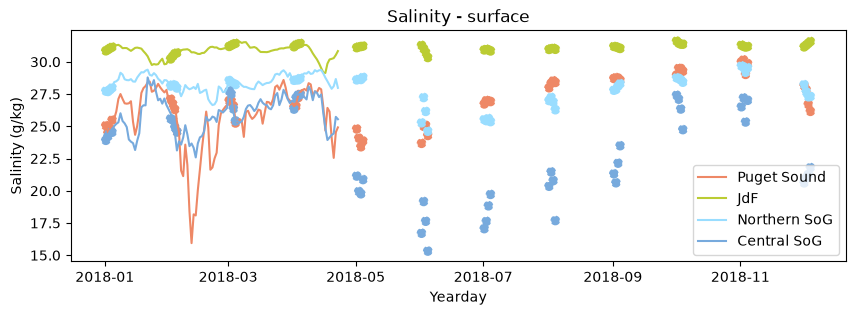

In [12]:
fig, ax = plt.subplots(1,1,figsize=(10,3))

depth_bool, y_bool, x_bool = booleans(change,'pug',depth=0)
ax.plot(change.time_counter,np.mean(change.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',label='Puget Sound')
ax.scatter(old.time_counter,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'jdf',depth=0)
ax.plot(change.time_counter,np.mean(change.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',label='JdF')
ax.scatter(old.time_counter,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'nsg',depth=0)
ax.plot(change.time_counter,np.mean(change.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',label='Northern SoG')
ax.scatter(old.time_counter,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF',ls='dashed')

depth_bool, y_bool, x_bool = booleans(change,'csg',depth=0)
ax.plot(change.time_counter,np.mean(change.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',label='Central SoG')
ax.scatter(old.time_counter,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD',ls='dashed')

ax.set_ylabel('Salinity (g/kg)')
ax.set_xlabel('Yearday')
ax.set_title('Salinity - surface')
ax.legend()

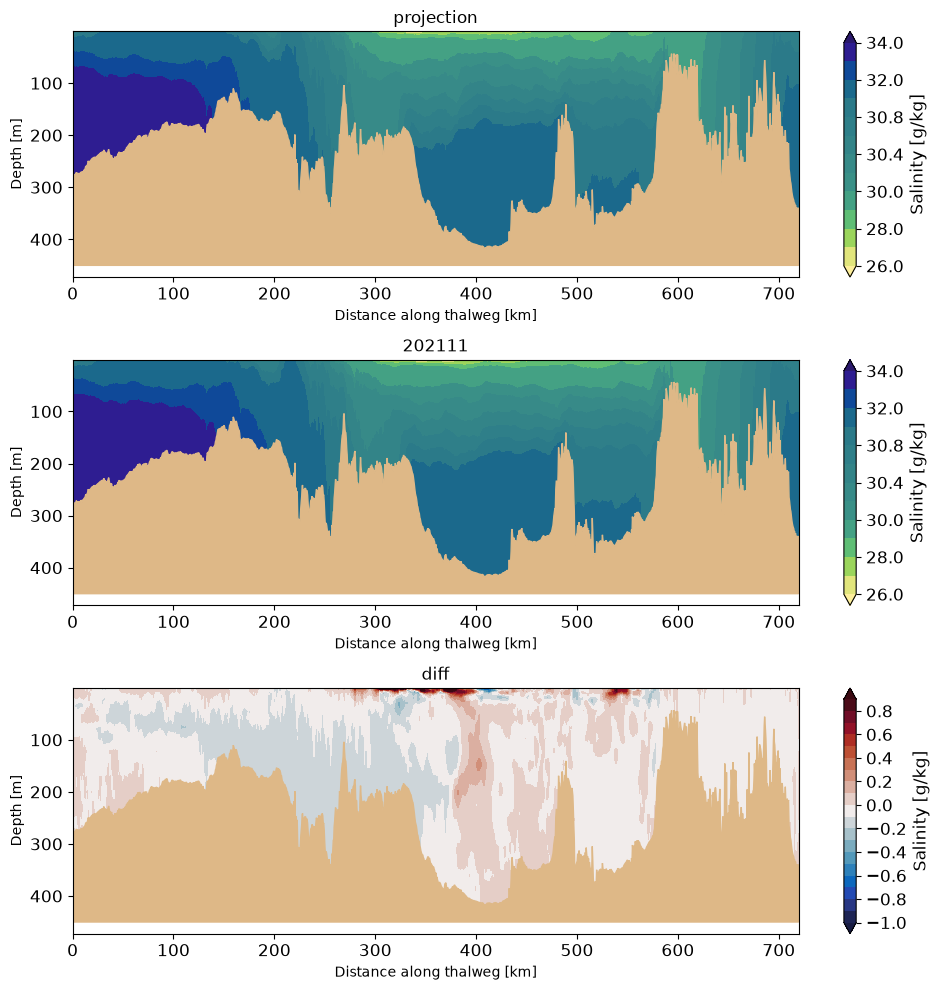

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1,figsize=(10,10))

#CHANGE
tit = 'projection'
data_to_plot = change['vosaline'].isel(time_counter=list(change.time_counter.values).index(np.datetime64('2018-04-01T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax1, data_to_plot, bathy, mesh, clevels='salinity', cmap = cm.haline_r, thalweg_file=thalweg_in)
cbar.set_label('Salinity [g/kg]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title(tit)

#original
tit = '202111'

data_to_plot = old['vosaline'].isel(time_counter=list(old.time_counter.values).index(np.datetime64('2018-04-01T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax2, data_to_plot, bathy, mesh, clevels='salinity', cmap = cm.haline_r, thalweg_file=thalweg_in)
cbar.set_label('Salinity [g/kg]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title(tit)

#change
diff = np.arange(-1,1,0.1)
tit = 'diff'
data_to_plot = change['vosaline'].isel(time_counter=list(change.time_counter.values).index(np.datetime64('2018-04-01T12:00:00.000000000'))).values - old['vosaline'].isel(time_counter=list(old.time_counter.values).index(np.datetime64('2018-04-01T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax3, data_to_plot, bathy, mesh, clevels=diff, cmap = cm.balance, thalweg_file=thalweg_in)
cbar.set_label('Salinity [g/kg]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_title(tit)

plt.tight_layout()